# House Price Prediction

## Objective
Predict house prices using property features such as area, bedrooms, bathrooms, and location.

## Goal
Build a machine learning regression model and evaluate its performance using MAE and RMSE.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
# Load Dataset

df = pd.read_csv("house.csv")

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


## Dataset Information

Checking dataset shape, columns and data types.

In [8]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset:
(2000, 10)

Columns:
Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


## Checking Missing Values

In [9]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [10]:
# Fill missing values if any

df.fillna(df.mean(numeric_only=True), inplace=True)

print("Missing values handled successfully.")

Missing values handled successfully.


## Statistical Summary

In [11]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


## Correlation Heatmap

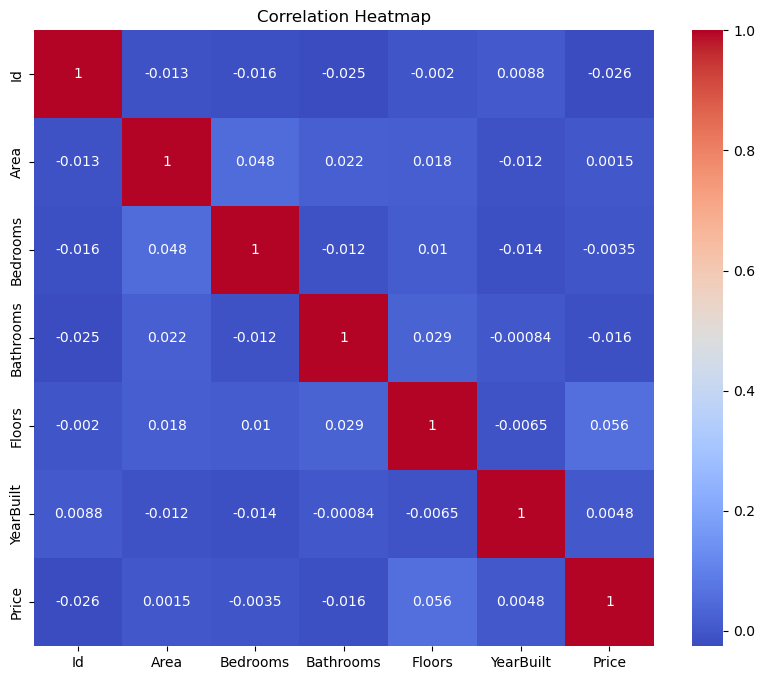

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

## House Price Distribution

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], kde=True)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

KeyError: 'price'

<Figure size 800x500 with 0 Axes>

## Area vs Price

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='area',
    y='price',
    data=df
)

plt.title("Area vs Price")

plt.show()

## Bedrooms vs Price

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='bedrooms',
    y='price',
    data=df
)

plt.title("Bedrooms vs Price")

plt.show()

## Data Preprocessing

Encoding categorical columns.

In [ ]:
# Convert location column into numerical values

encoder = LabelEncoder()

df['location'] = encoder.fit_transform(df['location'])

df.head()

## Feature Selection

In [ ]:
# Input Features

X = df[['area', 'bedrooms', 'bathrooms', 'location']]

# Target Variable

y = df['price']

## Splitting Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

## Model Training

Using Linear Regression.

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
results = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

results.head(10)

## Model Evaluation

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):")
print(mae)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error (RMSE):")
print(rmse)

## Actual vs Predicted Prices

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

## Feature Importance

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

# Final Insights

1. Data was successfully cleaned and preprocessed.
2. Linear Regression was used to predict house prices.
3. Area and location had significant effects on price.
4. MAE shows average prediction error.
5. RMSE measures overall prediction accuracy.
6. R² Score indicates how well the model explains house price variation.
7. The model can be used for basic real-estate price prediction.